# Q: Can you build such a model? 
    Prompt -> Model -> next character
    Please say yes/no in the chat.

    Raise your hand if you want to explain the process.

# Q: Prompt is a text. How do you convert it into rows and columns (instances and features)?

Each prompt is a single instance.
In case RNN, we have sequences. Each windows is a sequence.

Features -> DNN

"I want to drink "(X_text) --> milk (y_text)

* Characterwise we are predicting the outcome based on characters. We are predicting a single chr

10,000 unique characters in our characters set

Each characters will be represented by how many numbers: An array of 10000 numbers where everything is zero except for one.

### One hot encoding

a -> [1, 0, 0, .... ]
b -> [0, 1, 0, .... ]
c -> [0, 0, 1, .... ]
d -> [0, 0, 0, 1....]

A prompt with 50 characters, we are building dense neural network. How many total features in our input?
50 * 10000 -> half million features

In case of RNN, A prompt with 50 characters, will be fed one character at a time. Therefore the features are going to be 10,000.

Forward Pass (50 charatcers -> loss)
    RNN Cycle
        Step1: First Character(10,0000) + zeros(1000) -> Layer1 (1000) --> outcome1 (1000)
        Step2: Second Character(10,000) + outcome1(1000) --> Layer 1 --> outcome2
        ...
        step 50: 50th Character(10,000) + outcom49(1000) -> layer 1 -> outcome50
    Dense + Loss
        outcome50 --> dense layer (10000) -> numbers -> Softmax(big gets and small gets smaller (exp) -> probability (1) (divide by sum).) -> Cross Entropy Loss

    prediction = [.5, .2, .3]
    actual = [1, 0, 0]

    cross_entropy_loss = -(1 * log(.5) + 0 * log(.2) + 0 * log(.3))

# Gradient Descent (RNN - BPTT)
We feed 50 charatcers
    RNN Cycle (50 Times) + DNN -> Softmax -> Crossentropy -> Loss1
we slight increased one of weights -> loss2

gradient1 = (loss2 - loss1)/increase in weight1
gradient2 = (loss2 - loss1)/increase in weight2
...

weight1 -= eta * gradient1
weight2 -= eta * gradient2
..

Go to next batch
repeat the process - next epoch.



## How would you build better next character predictor (GPT)
- download the data from entire planet
- token (syllabal) - few charatcers together - tiktoken
- Make it attention
- increase the layers - make the model super deep
- Throw more GPU on it make the compute parallel, train models parallely

## Now, we have a good next character predictor,
## How do you frame sentence from GPT
- repeatedly calling the model and picking the best character, temperature
- Beam search -> we pluck top 3 and feed to 3 models -> pick the best so far.

## How to make this product Q/A?
- You can train the model on Q/A

Q: Capital of india?
A: Delhi

Q: Capital of india?A:  -> Model -> D
Q: Capital of india?A: D -> Model -> e
Q: Capital of india?A: De -> Model -> l
Q: Capital of india?A: Del -> Model -> h
Q: Capital of india?A: Delh -> Model -> i
Q: Capital of india?A: Delhi -> Model -> <END>

# RLHF - Reeinforcement learning on human feedback

# Trained a second model as Judge.

# Model was trained using Judge's feedback

Model (Q) -> Text, Code

Run Code -> Result -> Model-> next



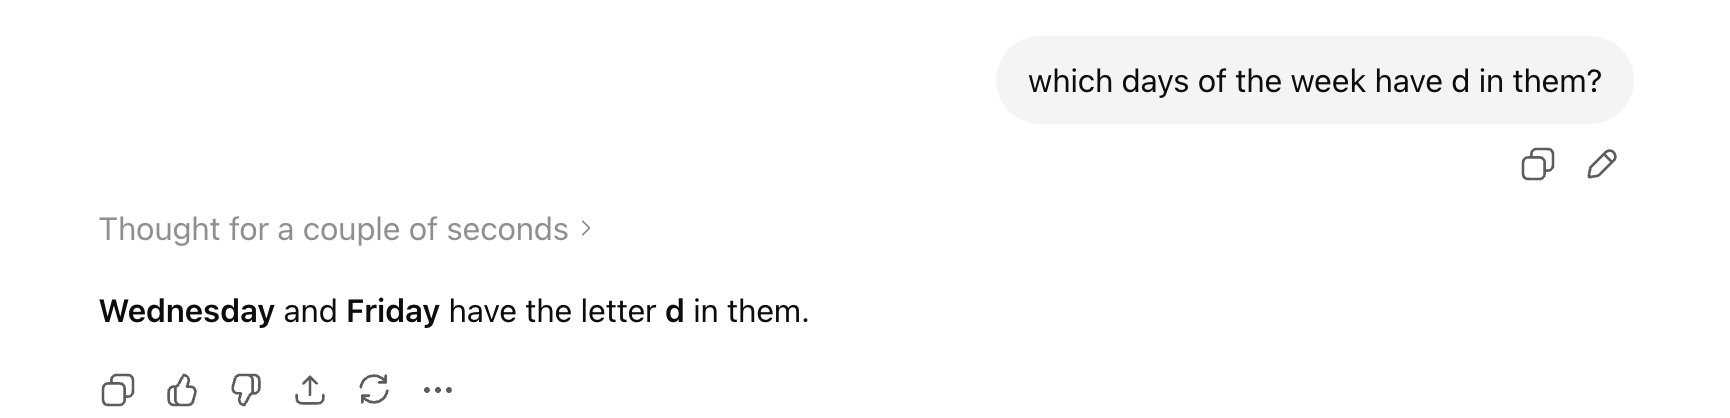

In [ ]:
Q: WHy?
A: Since the text or days of the week are converted into ticktoken -> model can't characters.

Q: How to solve it? 
A: Multi Step.



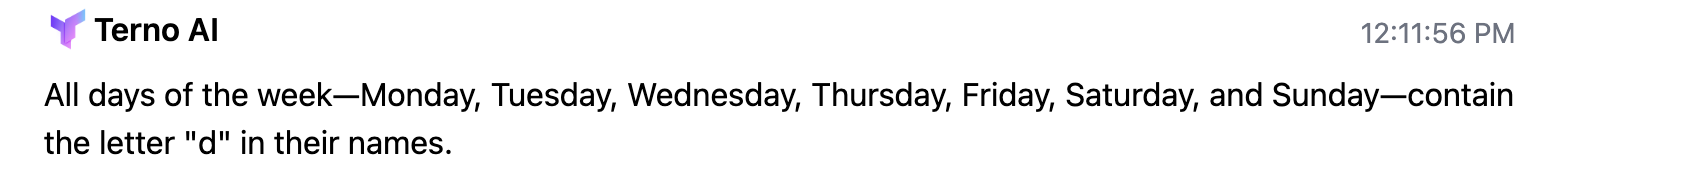

In [ ]:

    You are an intelligent data scientist who can code to answer the question. 
    Product the code in <code> </code> block. 

    --> ChatGPT -->

    <code>
    # List of days of the week
    week_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    # Find days containing the letter 'd' (case-insensitive)
    days_with_d = [day for day in week_days if 'd' in day.lower()]
    print('Days of the week with the letter "d":', days_with_d)
    </code>

    -> Terno runs the code generated and sends back the result to ChatGPT --> 

    Days of the week with the letter "d": ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    -> ChatGpt -> 
    All days of the week—Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, and Sunday—contain the letter "d" in their names.

    How else can I help you today?


In [ ]:
# Question -> LLM -> Thought/Code -> Output / Error -> LLM -> Thought/Code Output / Error -> LLM -> Stop.

In [ ]:

import numpy as np

# Softmax
arr = np.array([10, 1, 1])
print(arr)
arr = np.exp(arr)
print(arr)
arr = arr/sum(arr)
print(arr)


[10  1  1]
[2.20264658e+04 2.71828183e+00 2.71828183e+00]
[9.99753241e-01 1.23379352e-04 1.23379352e-04]


In [16]:
np.log(.9), np.log(.1)

(np.float64(-0.10536051565782628), np.float64(-2.3025850929940455))

In [ ]:
# Cross entropy

actual = [1, 0, 0]
np.sum(-np.log(arr) * actual)


np.float64(0.0002467891532250607)

In [ ]:
actual = [1, 0, 0] 
predicted1 = [.9, .1, 0]
predicted2 = [.8, .1, 0.1]
predicted3 = [.1, .7, .1]

L1 = loss(predicted1, actual)
L2 = loss(predicted2, actual)

So, L2 should be bigger than L1

And -log makes it so.

# Cross Entropy

In [23]:
actual = [1, 0, 0] 
predicted1 = [.9, .1, 0.0001]
predicted2 = [.8, .1, 0.1]
predicted3 = [.1, .7, .1]

def cross_entropy(actual, predicted):
    return np.sum(-np.log(predicted)* actual)

cross_entropy(actual, predicted1),cross_entropy(actual, predicted2),cross_entropy(actual, predicted3)

(np.float64(0.10536051565782628),
 np.float64(0.2231435513142097),
 np.float64(2.3025850929940455))

In [18]:
-np.log([.8, .9])

array([0.22314355, 0.10536052])

In [ ]:
# One hot encoding
Ford -> [1, 0, 0, .. 1millions]
Nissan -> [0, 1, 0]
ferrari -> [0, 0, 1]
...
1 millions


Car Model (1 millions) -> Layer 1 (10000) --> Layer 2 (1500) -> layer 3(1500) -> layer 3(1500) --> -> layer 3(1) --> price

Ford -> Car Model (1 million) -> Layer 1 (10000) --> Layer 2 (1500) -> layer 3(1500) --> embedding_ford
Nissan -> Car Model (1 million) -> Layer 1 (10000) --> Layer 2 (1500) -> layer 3(1500) --> embedding_nissan

#embedding_ford.dot_product(embedding_nissan)

